In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Linear Regression : Continuous Values , numerical Data
# Linear Regression -> Y=bx+c where b is biasness and c is coeffieceint
#    X	Y_Actual	C	Y_Pred = X*C+1
#   10	0.1	        0.1	     2
#   20	0.2	        0.2	     0.2
#   30	0.3	        0.3	     0.9
#   40	0.4	        0.4	     0.7
#   50	0.5	        0.5	     0.5


In [5]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [14]:
df.shape

(1338, 7)

In [15]:
df.duplicated().sum()

np.int64(1)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.shape

(1337, 7)

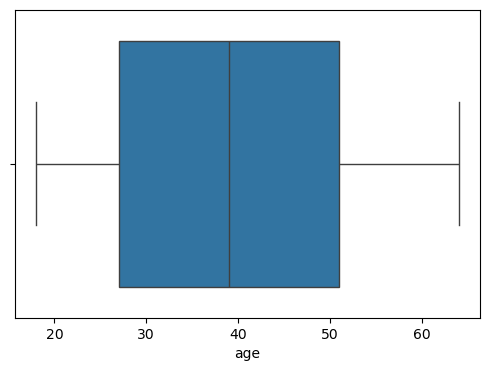

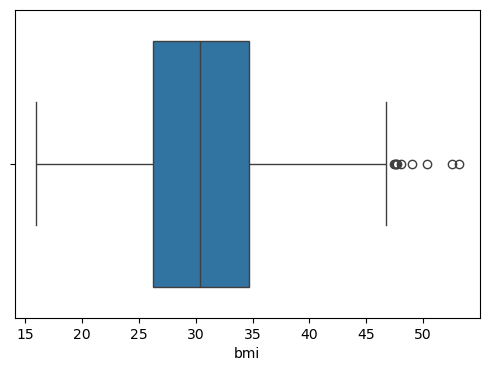

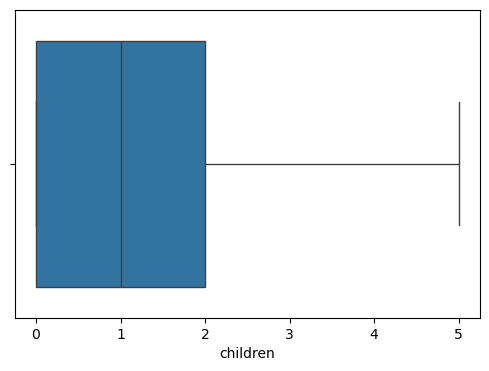

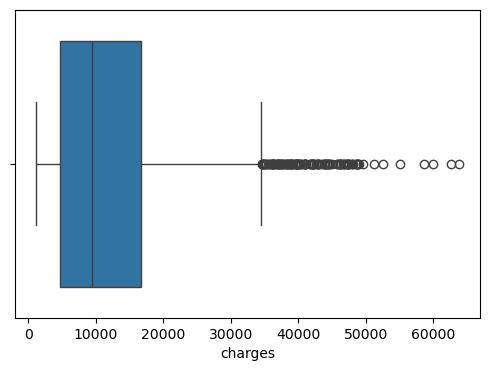

In [24]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

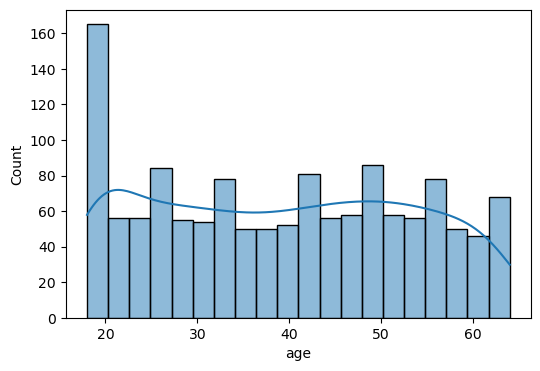

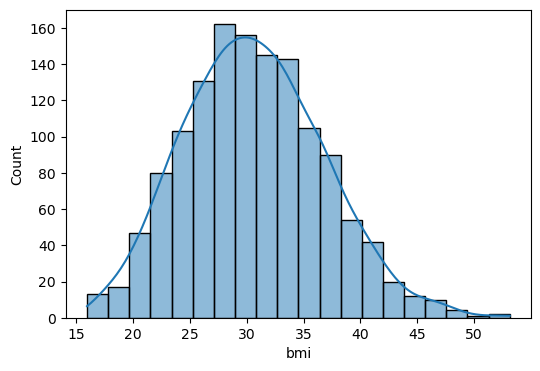

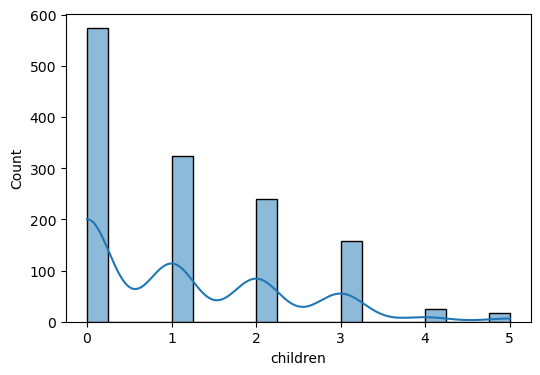

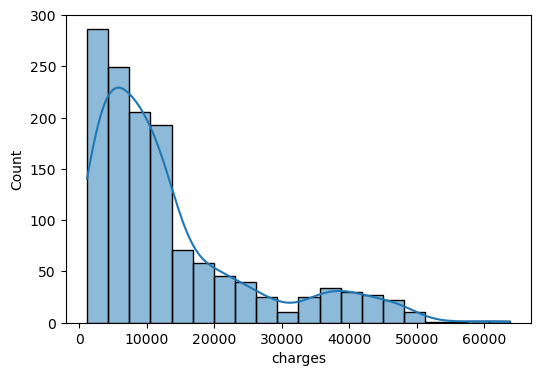

In [28]:
for col in numeric_columns:
     plt.figure(figsize=(6, 4))
     sns.histplot(x=df[col],kde=True,bins=20)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['charges'] = scaler.fit_transform(df[['charges']])
df['age'] = scaler.fit_transform(df[['age']])
df['bmi'] = scaler.fit_transform(df[['bmi']])

In [32]:
df

,age,sex,bmi,children,smoker,region,charges
0,-1.440418,female,-0.453160,0,yes,southwest,0.297857
1,-1.511647,male,0.509422,1,no,southeast,-0.954381
2,-0.799350,male,0.383155,3,no,southeast,-0.729373
3,-0.443201,male,-1.305052,0,no,northwest,0.719104
4,-0.514431,male,-0.292456,0,no,northwest,-0.777499
...,...,...,...,...,...,...,...
1333,0.767704,male,0.050269,3,no,northwest,-0.221263
1334,-1.511647,female,0.206053,0,no,northeast,-0.914695
1335,-1.511647,female,1.014490,0,no,southeast,-0.962287
1336,-1.297958,female,-0.797524,0,no,southwest,-0.931054


In [37]:
from sklearn.model_selection import train_test_split

In [36]:
x = df[['charges']]
Y = df['smoker']

In [38]:
x_train , x_test , Y_train , Y_test = train_test_split(x,Y,test_size=0.1)

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
LR = LogisticRegression()

In [41]:
LR.fit(x_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
Y_pred = LR.predict(x_test)

In [43]:
Y_pred

array(['no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no',
       'no', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'yes', 'no', 'yes', 'yes', 'no', 'no', 'no', 'yes',
       'no', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no',
       'no', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'yes', 'yes',
       'no', 'no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'yes', 'no',
       'yes', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no', 'no', 'no',
       'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no',
       'no', 'no', 'yes', 'no', 'yes'], dtype=object)

In [57]:
comparison = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': Y_pred
})

comparison.info()

<class 'pandas.core.frame.DataFrame'>
Index: 134 entries, 455 to 637
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Actual     134 non-null    object
 1   Predicted  134 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [53]:
from sklearn.metrics import classification_report
print("Accuracy:", accuracy)
print(classification_report(Y_test, Y_pred))

Accuracy: 0.8805970149253731
              precision    recall  f1-score   support

          no       0.90      0.94      0.92       101
         yes       0.79      0.70      0.74        33

    accuracy                           0.88       134
   macro avg       0.85      0.82      0.83       134
weighted avg       0.88      0.88      0.88       134



In [58]:
df1 = pd.read_csv("heart.csv")

In [59]:
df1

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [62]:
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Salary": np.random.randint(25000, 120000, n),
    "Experience": np.random.randint(0, 30, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Education": np.random.choice(
        ["High School", "Graduate", "Post Graduate"], n
    ),
    "City": np.random.choice(
        ["Delhi", "Mumbai", "Bangalore", "Chennai"], n
    )
})

df.head()

,Age,Salary,Experience,Gender,Education,City
0,56,39382,3,Female,Post Graduate,Mumbai
1,46,109291,5,Female,High School,Mumbai
2,32,28756,18,Female,High School,Mumbai
3,25,45609,5,Male,High School,Delhi
4,38,41478,1,Female,High School,Delhi


In [63]:
df["Purchased"] = np.where(
    (df["Salary"] > 70000) &
    (df["Age"] > 30) &
    (df["Experience"] > 5),
    "Yes",
    "No"
)

df.head()

,Age,Salary,Experience,Gender,Education,City,Purchased
0,56,39382,3,Female,Post Graduate,Mumbai,No
1,46,109291,5,Female,High School,Mumbai,No
2,32,28756,18,Female,High School,Mumbai,No
3,25,45609,5,Male,High School,Delhi,No
4,38,41478,1,Female,High School,Delhi,No


In [64]:
encoder = LabelEncoder()

categorical_columns = ["Gender", "Education", "City", "Purchased"]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Salary,Experience,Gender,Education,City,Purchased
0,56,39382,3,0,2,3,0
1,46,109291,5,0,1,3,0
2,32,28756,18,0,1,3,0
3,25,45609,5,1,1,2,0
4,38,41478,1,0,1,2,0


In [65]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print(X.head())
print(y.head())

   Age  Salary  Experience  Gender  Education  City
0   56   39382           3       0          2     3
1   46  109291           5       0          1     3
2   32   28756          18       0          1     3
3   25   45609           5       1          1     2
4   38   41478           1       0          1     2
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [67]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [69]:
y_pred = model.predict(X_test)

y_pred

array([0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0])

In [70]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.875


In [71]:
import pickle

In [72]:
with open("logistic_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [73]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!
